In [112]:
#---------------------------------------
# Load Dataset
#---------------------------------------
import pandas as pd
from google.colab import files
files.upload()
# Load dataset
df = pd.read_csv("online_retail.csv")

df.head()
df.tail()

Saving online_retail.csv to online_retail.csv


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
541904,581587,22613,PACK OF 20 SPACEBOY NAPKINS,12,2011-12-09 12:50:00,0.85,12680.0,France
541905,581587,22899,CHILDREN'S APRON DOLLY GIRL,6,2011-12-09 12:50:00,2.10,12680.0,France
541906,581587,23254,CHILDRENS CUTLERY DOLLY GIRL,4,2011-12-09 12:50:00,4.15,12680.0,France
541907,581587,23255,CHILDRENS CUTLERY CIRCUS PARADE,4,2011-12-09 12:50:00,4.15,12680.0,France
541908,581587,22138,BAKING SET 9 PIECE RETROSPOT,3,2011-12-09 12:50:00,4.95,12680.0,France


In [113]:
df.info()
df.describe()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


(541909, 8)

In [114]:
df['Country'].value_counts().head(10)

,count
Country,
United Kingdom,495478
Germany,9495
France,8557
EIRE,8196
Spain,2533
Netherlands,2371
Belgium,2069
Switzerland,2002
Portugal,1519


In [115]:
df['Revenue']=df['Quantity'] * df['UnitPrice']
df['Revenue'].sum()

np.float64(9747747.933999998)

In [116]:
country_revenue = df.groupby('Country')['Revenue'].sum().sort_values(ascending=False)
country_revenue.head(10)

,Revenue
Country,
United Kingdom,8187806.364
Netherlands,284661.540
EIRE,263276.820
Germany,221698.210
France,197403.900
Australia,137077.270
Switzerland,56385.350
Spain,54774.580
Belgium,40910.960


In [117]:
customer_revenue = df.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)
customer_revenue.head(10)

,Revenue
CustomerID,
14646.0,279489.02
18102.0,256438.49
17450.0,187482.17
14911.0,132572.62
12415.0,123725.45
14156.0,113384.14
17511.0,88125.38
16684.0,65892.08
13694.0,62653.10


In [118]:
# Identify canceled transactions using invoice numbers starting with 'C'
df[df['InvoiceNo'].astype(str).str.startswith('C')].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96


In [119]:
df['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(9288)

In [120]:
# Identify refund transactions with negative quantities
df[df['Quantity'] < 0].head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
141,C536379,D,Discount,-1,2010-12-01 09:41:00,27.50,14527.0,United Kingdom,-27.50
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,2010-12-01 09:49:00,4.65,15311.0,United Kingdom,-4.65
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,2010-12-01 10:24:00,1.65,17548.0,United Kingdom,-19.80
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,2010-12-01 10:24:00,0.29,17548.0,United Kingdom,-6.96


In [121]:
(df['Quantity'] < 0).sum()

np.int64(10624)

In [122]:
round((df['Quantity'] < 0).mean()*100,2)

np.float64(1.96)

In [123]:
# Convert invoice date to datetime format
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [124]:
df['Month'] = df['InvoiceDate'].dt.to_period('M')
monthly_revenue = df.groupby('Month')['Revenue'].sum()
monthly_revenue.head()

,Revenue
Month,
2010-12,748957.020
2011-01,560000.260
2011-02,498062.650
2011-03,683267.080
2011-04,493207.121


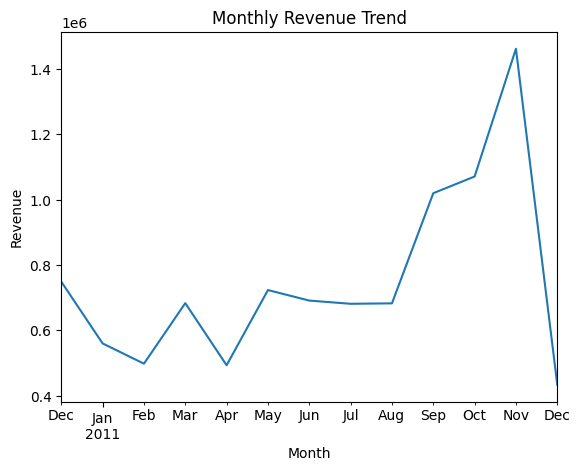

In [125]:
#------------------------------------
# Monthly Revenue Trend Analysis
#------------------------------------
# Analyze monthly revenue trends to identify seasonality
import matplotlib.pyplot as plt

monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

# Revenue peaked in November, suggesting strong seasonal demand

In [126]:
df['InvoiceDate'].max()
df.groupby('Month').size()

,0
Month,
2010-12,42481
2011-01,35147
2011-02,27707
2011-03,36748
2011-04,29916
2011-05,37030
2011-06,36874
2011-07,39518
2011-08,35284


In [198]:
# Remove refunded/canceled transactions for customer behavior analysis
df_clean = df[df['Quantity'] > 0].copy()
df_clean = df[df['UnitPrice'] > 0].copy()
df_clean.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34,2010-12


In [128]:
customer_revenue = df_clean.groupby('CustomerID')['Revenue'].sum()
customer_revenue = customer_revenue.sort_values(ascending=False)
customer_revenue.head(10)

,Revenue
CustomerID,
14646.0,279489.02
18102.0,256438.49
17450.0,187482.17
14911.0,132572.62
12415.0,123725.45
14156.0,113384.14
17511.0,88125.38
16684.0,65892.08
13694.0,62653.10


In [129]:
customer_freq = df_clean.groupby('CustomerID')['InvoiceNo'].nunique()

In [130]:
customer_summary = df_clean.groupby('CustomerID').agg({'Revenue' : 'sum', 'InvoiceNo' : 'nunique'})
customer_summary.columns = ['TotalRevenue', 'Frequency']
customer_summary = customer_summary.sort_values(by='TotalRevenue', ascending = False)
customer_summary.head(10)

,TotalRevenue,Frequency
CustomerID,,
14646.0,279489.02,76
18102.0,256438.49,62
17450.0,187482.17,55
14911.0,132572.62,248
12415.0,123725.45,26
14156.0,113384.14,66
17511.0,88125.38,46
16684.0,65892.08,31
13694.0,62653.10,60


In [131]:
customer_summary.describe()

,TotalRevenue,Frequency
count,4371.000000,4371.000000
mean,1898.894032,5.075726
std,8220.235339,9.332529
min,-4287.630000,1.000000
25%,293.785000,1.000000
50%,648.410000,3.000000
75%,1611.860000,5.000000
max,279489.020000,248.000000


In [132]:
# Define VIP customers as top 5% based on total revenue
vip_threshold = customer_summary['TotalRevenue'].quantile(0.95)
vip_customers = customer_summary[customer_summary['TotalRevenue'] >= vip_threshold]
vip_customers

,TotalRevenue,Frequency
CustomerID,,
14646.0,279489.02,76
18102.0,256438.49,62
17450.0,187482.17,55
14911.0,132572.62,248
12415.0,123725.45,26
...,...,...
13050.0,5684.61,28
14110.0,5669.65,13
16553.0,5664.57,14


In [133]:
# Correlation between total revenue and purchase frequency
customer_summary.corr()

# Moderate positive correlation : frequent buyers tend to generate higher revenue
# However, frequency alone does not fully explain revenue differences

,TotalRevenue,Frequency
TotalRevenue,1.000000,0.565639
Frequency,0.565639,1.000000


In [134]:
vip_threshold = customer_summary['TotalRevenue'].quantile(0.95)
customer_summary['is_vip'] = customer_summary['TotalRevenue'] >= vip_threshold

In [135]:
customer_summary.groupby('is_vip').mean()

,TotalRevenue,Frequency
is_vip,,
False,1027.696557,3.869942
True,18415.843425,27.936073


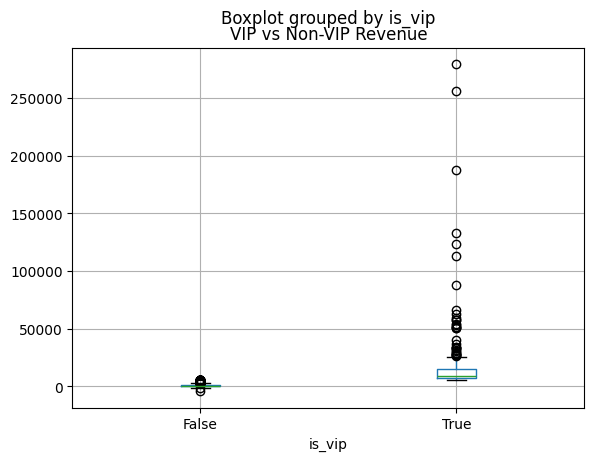

In [136]:
import matplotlib.pyplot as plt

customer_summary.boxplot(column = 'TotalRevenue', by= 'is_vip')
plt.title('VIP vs Non-VIP Revenue')
plt.show()

# Distribution heavily skewed due to extreme high-value customers (outliers)
# Revenue distribution is highly skewed, with a small number of customers contributing disproportionately high values

In [137]:
# Compare average purchase frequency between VIP and non-VIP customers
customer_summary.groupby('is_vip')['Frequency'].mean()

# VIP customers show significantly higher purchase frequency than non-VIP customers
# Initial observation : revenue gap is larger than frequency gap
# suggesting possible influence of average order value per purchase

,Frequency
is_vip,
False,3.869942
True,27.936073


In [138]:
#-----------------------------------
# Price Distribution Analysis
#-----------------------------------
df_price_clean = df_clean[df_clean['UnitPrice']>0]
df_price_clean['UnitPrice'].describe()

,UnitPrice
count,539392.000000
mean,4.673648
std,94.614722
min,0.001000
25%,1.250000
50%,2.080000
75%,4.130000
max,38970.000000


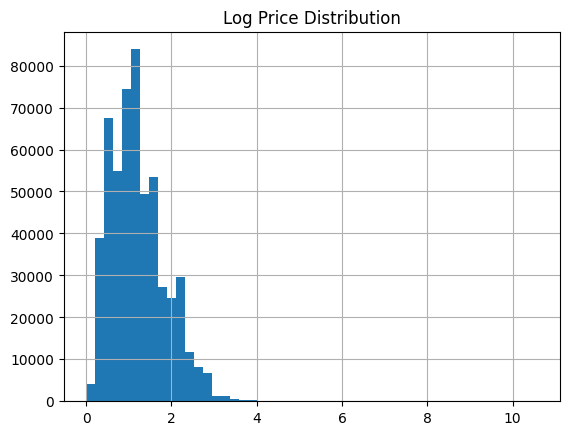

In [139]:
# Log-Transformed Price Distribution
# Apply log transformation to reduce skewness in price distribution
import numpy as np
import matplotlib.pyplot as plt
np.log1p(df_price_clean['UnitPrice']).hist(bins=50)
plt.title("Log Price Distribution")
plt.show()

# Most product prices are concentrated in the lower price range

In [140]:
# Product Count by Price Range
pd.cut(df_price_clean['UnitPrice'], bins=[0,1,2,5,10,20,50]).value_counts()

,count
UnitPrice,
"(2, 5]",198477
"(1, 2]",140627
"(0, 1]",112296
"(5, 10]",62973
"(10, 20]",20849
"(20, 50]",2897


Initial anlysis suggested that higher revenue may be driven by larger spending per purchase.
However, price distribution analysis showed minimal pricing differences between groups.
Revenue growth appeared to be behavior-driven rather than price-driven.

In [141]:
# Assign the most frequent purchase country to each customer
customer_country = df_clean.groupby('CustomerID')['Country'].first()
df_clean.groupby('CustomerID')['Country'].nunique().sort_values(ascending = False).head(100)
customer_country = df_clean.groupby('CustomerID')['Country'].agg(lambda x: x.value_counts().index[0])

In [142]:
customer_summary = customer_summary.join(customer_country)

In [143]:
customer_summary.head()

,TotalRevenue,Frequency,is_vip,Country
CustomerID,,,,
14646.0,279489.02,76,True,Netherlands
18102.0,256438.49,62,True,United Kingdom
17450.0,187482.17,55,True,United Kingdom
14911.0,132572.62,248,True,EIRE
12415.0,123725.45,26,True,Australia


In [144]:
# Filter VIP customers
vip_only = customer_summary[customer_summary['is_vip']]
vip_only.head()

,TotalRevenue,Frequency,is_vip,Country
CustomerID,,,,
14646.0,279489.02,76,True,Netherlands
18102.0,256438.49,62,True,United Kingdom
17450.0,187482.17,55,True,United Kingdom
14911.0,132572.62,248,True,EIRE
12415.0,123725.45,26,True,Australia


In [145]:
# Analyze distribution of VIP customers across countries
vip_country_count = vip_only['Country'].value_counts()
vip_country_count.head()

,count
Country,
United Kingdom,180
Germany,11
France,8
Switzerland,3
Japan,2


In [146]:
# VIP revenue by country
vip_country_revenue = vip_only.groupby('Country')['TotalRevenue'].sum().sort_values(ascending = False)
vip_country_revenue.head()

,TotalRevenue
Country,
United Kingdom,3011868.19
Netherlands,279489.02
EIRE,245956.76
Australia,130141.84
Germany,103433.88


In [147]:
# VIP ratio by country
country_total = customer_summary['Country'].value_counts()
country_vip = vip_only['Country'].value_counts()

vip_ratio = (country_vip / country_total).sort_values(ascending = False)
vip_ratio.head(10)

,count
Country,
Singapore,1.000000
EIRE,0.666667
Japan,0.250000
Australia,0.222222
Cyprus,0.166667
Switzerland,0.150000
Sweden,0.125000
Denmark,0.125000
Germany,0.115789


The United Kingdom accounts for the majority of both total revenue and VIP customers.
However, some countries show a relatively high VIP ratio despite smaller absolute size, indicating potential high-value customer markets.

Singapore is identified as a particularly promising emerging high-value market.

In [148]:
vip_only.head()

,TotalRevenue,Frequency,is_vip,Country
CustomerID,,,,
14646.0,279489.02,76,True,Netherlands
18102.0,256438.49,62,True,United Kingdom
17450.0,187482.17,55,True,United Kingdom
14911.0,132572.62,248,True,EIRE
12415.0,123725.45,26,True,Australia


In [149]:
vip_ids = vip_only.index

In [150]:
vip_data = df_clean[df_clean['CustomerID'].isin(vip_ids)]

In [151]:
#-------------------------------------------
# VIP Top Product Analysis
#-------------------------------------------
# Top 10 products purchased by VIP customers
vip_products = vip_data.groupby('Description')['Quantity'].sum().sort_values(ascending = False)
vip_products.head(10)

,Quantity
Description,
JUMBO BAG RED RETROSPOT,29249
WORLD WAR 2 GLIDERS ASSTD DESIGNS,26365
POPCORN HOLDER,20648
PACK OF 72 RETROSPOT CAKE CASES,19351
WHITE HANGING HEART T-LIGHT HOLDER,18987
PACK OF 12 LONDON TISSUES,17710
RABBIT NIGHT LIGHT,17641
ASSORTED COLOUR BIRD ORNAMENT,16633
PACK OF 60 PINK PAISLEY CAKE CASES,15866


In [152]:
# Top 10 products by total revenue
vip_product_revenue = vip_data.groupby('Description')['Revenue'].sum().sort_values(ascending = False)
vip_product_revenue.head(10)

,Revenue
Description,
REGENCY CAKESTAND 3 TIER,86070.60
JUMBO BAG RED RETROSPOT,52310.67
WHITE HANGING HEART T-LIGHT HOLDER,51617.05
CHILLI LIGHTS,34339.76
RABBIT NIGHT LIGHT,33386.08
PARTY BUNTING,31171.48
BLACK RECORD COVER FRAME,30663.47
ASSORTED COLOUR BIRD ORNAMENT,25619.53
JUMBO BAG PINK POLKADOT,25388.79


In [153]:
# Compare VIP and non-VIP customers
non_vip_data = df_clean[~df_clean['CustomerID'].isin(vip_ids)]

non_vip_products = non_vip_data.groupby('Description')['Quantity'].sum().sort_values(ascending = False)
non_vip_products.head(10)

,Quantity
Description,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,27482
ASSORTED COLOUR BIRD ORNAMENT,19748
JUMBO BAG RED RETROSPOT,18110
PACK OF 72 RETROSPOT CAKE CASES,16688
WHITE HANGING HEART T-LIGHT HOLDER,16326
POPCORN HOLDER,15686
VICTORIAN GLASS HANGING T-LIGHT,14108
ASSORTED COLOURS SILK FAN,14021
CHARLOTTE BAG SUKI DESIGN,13259


Product-level analysis was conducted to identify which products contribute most to VIP customer purchases and revenue generation.

VIP and non-VIP customers show different product preferences, with only limited overlap in purchased items. This suggests that VIP customers exhibit distinct consumption patterns, and specific product categories may play an important role in driving high-value customer retention and revenue growth.

In [154]:
# Top 10 products purchased by VIP customers
vip_top10 = vip_products.head(10).index

In [155]:
vip_top_data = df_clean[df_clean['Description'].isin(vip_top10)]
vip_top_data.head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue,Month
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30,2010-12
9,536367,84879,ASSORTED COLOUR BIRD ORNAMENT,32,2010-12-01 08:34:00,1.69,13047.0,United Kingdom,54.08,2010-12
44,536370,22492,MINI PAINT SET VINTAGE,36,2010-12-01 08:45:00,0.65,12583.0,France,23.40,2010-12
49,536373,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 09:02:00,2.55,17850.0,United Kingdom,15.30,2010-12
66,536375,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 09:32:00,2.55,17850.0,United Kingdom,15.30,2010-12
96,536378,21212,PACK OF 72 RETROSPOT CAKE CASES,120,2010-12-01 09:37:00,0.42,14688.0,United Kingdom,50.40,2010-12
98,536378,21977,PACK OF 60 PINK PAISLEY CAKE CASES,24,2010-12-01 09:37:00,0.55,14688.0,United Kingdom,13.20,2010-12
177,536386,85099B,JUMBO BAG RED RETROSPOT,100,2010-12-01 09:57:00,1.65,16029.0,United Kingdom,165.00,2010-12
220,536390,85123A,WHITE HANGING HEART T-LIGHT HOLDER,64,2010-12-01 10:19:00,2.55,17511.0,United Kingdom,163.20,2010-12
234,536390,85099B,JUMBO BAG RED RETROSPOT,100,2010-12-01 10:19:00,1.65,17511.0,United Kingdom,165.00,2010-12


In [156]:
# Average price of top VIP products
vip_top_data.groupby('Description')['UnitPrice'].mean().sort_values(ascending = False)

,UnitPrice
Description,
WHITE HANGING HEART T-LIGHT HOLDER,3.209670
JUMBO BAG RED RETROSPOT,2.473701
RABBIT NIGHT LIGHT,2.375385
ASSORTED COLOUR BIRD ORNAMENT,1.722032
POPCORN HOLDER,1.010983
MINI PAINT SET VINTAGE,0.781564
PACK OF 72 RETROSPOT CAKE CASES,0.755986
PACK OF 60 PINK PAISLEY CAKE CASES,0.741217
PACK OF 12 LONDON TISSUES,0.446925


In [157]:
# Total revenue generated by top VIP products
vip_top_data.groupby('Description')['Revenue'].sum().sort_values(ascending = False)

,Revenue
Description,
WHITE HANGING HEART T-LIGHT HOLDER,99668.47
JUMBO BAG RED RETROSPOT,92356.03
RABBIT NIGHT LIGHT,66756.59
ASSORTED COLOUR BIRD ORNAMENT,58959.73
POPCORN HOLDER,33969.46
PACK OF 72 RETROSPOT CAKE CASES,21059.72
MINI PAINT SET VINTAGE,16810.42
WORLD WAR 2 GLIDERS ASSTD DESIGNS,13587.93
PACK OF 60 PINK PAISLEY CAKE CASES,12189.47


In [158]:
# Purchase quantity of top VIP products
vip_top_data.groupby('Description')['Quantity'].sum().sort_values(ascending = False)

,Quantity
Description,
WORLD WAR 2 GLIDERS ASSTD DESIGNS,53847
JUMBO BAG RED RETROSPOT,47359
ASSORTED COLOUR BIRD ORNAMENT,36381
POPCORN HOLDER,36334
PACK OF 72 RETROSPOT CAKE CASES,36039
WHITE HANGING HEART T-LIGHT HOLDER,35313
RABBIT NIGHT LIGHT,30680
MINI PAINT SET VINTAGE,26437
PACK OF 12 LONDON TISSUES,26111


In [159]:
customer_quantity = df_clean.groupby('CustomerID')['Quantity'].sum()
customer_summary['TotalQuantity'] = customer_quantity

In [160]:
customer_summary['AvgQuantityPerVisit'] = customer_summary['TotalQuantity']/customer_summary['Frequency']

In [161]:
# Compare average quantity per visit between VIP and non-VIP customers
customer_summary.groupby('is_vip')['AvgQuantityPerVisit'].mean()

,AvgQuantityPerVisit
is_vip,
False,180.402770
True,451.399942


### Behavioral Analysis Summary

VIP customers showed significantly higher purchase frequency and larger purchase quantities per visit compared to non-VIP customers.

Combined with the minimal pricing differences observed between customer groups, this suggests that VIP revenue growth was primarily driven by repeat purchasing behavior rather than higher product prices.

In [162]:
# Monetary : total revenue generated by each customer
monetary = df.groupby('CustomerID')['Revenue'].sum()

In [163]:
# Frequency : total number of purchases per customer
frequency = df_clean.groupby('CustomerID')['InvoiceNo'].nunique()

In [199]:
# Recency : days since the customer's most recent purchase
import pandas as pd

df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
recency = df_clean.groupby('CustomerID')['InvoiceDate'].max()
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
recency = (snapshot_date - recency).dt.days

In [165]:
rfm = pd.DataFrame({'Recency' : recency, 'Frequency' : frequency, 'Monetary' : monetary})

In [166]:
# Assign RFM scores using 5-level quantile segmentation
rfm['R_score'] = pd.qcut(rfm['Recency'].rank(method = 'first'),5,labels = [5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method = 'first'),5,labels = [1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'].rank(method = 'first'),5,labels = [1,2,3,4,5])

In [167]:
rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score
CustomerID,,,,,,
12346.0,326.0,2.0,0.00,1,2,1
12347.0,2.0,7.0,4310.00,5,4,5
12348.0,75.0,4.0,1797.24,2,3,4
12349.0,19.0,1.0,1757.55,4,1,4
12350.0,310.0,1.0,334.40,1,1,2


In [168]:
# Combine RFM scores into a single customer segment code
rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

In [169]:
# Count customers with RFM score 555
(rfm['RFM_score'] == '555').sum()

np.int64(342)

In [170]:
# Calculate ratio of 555 customers
(rfm['RFM_score'] == '555').mean()

np.float64(0.07822506861848125)

In [171]:
vip_revenue = rfm[rfm['RFM_score'] == '555'].index
df[df['CustomerID'].isin(vip_revenue)]['Revenue'].sum()/ df['Revenue'].sum()

np.float64(0.38931957367948905)

RFM analysis showed that VIP customers, representing only 7.9% of total customers, contributed approximately 39% of total revenue.

This reflects a Pareto-like revenue structure, where a small group of high-value customers drives a disproportionate share of business performance, highlighting the importance of VIP customer retention.

In [172]:
import numpy as np
rfm_sorted = rfm.sort_values('Monetary', ascending = False)

rfm_sorted['cum_revenue'] = rfm_sorted['Monetary'].cumsum()

rfm_sorted['cum_ratio'] = rfm_sorted['cum_revenue'] / rfm_sorted['Monetary'].sum()

rfm_sorted['cum_customers'] = np.arange(1,len(rfm_sorted)+1) / len(rfm_sorted)

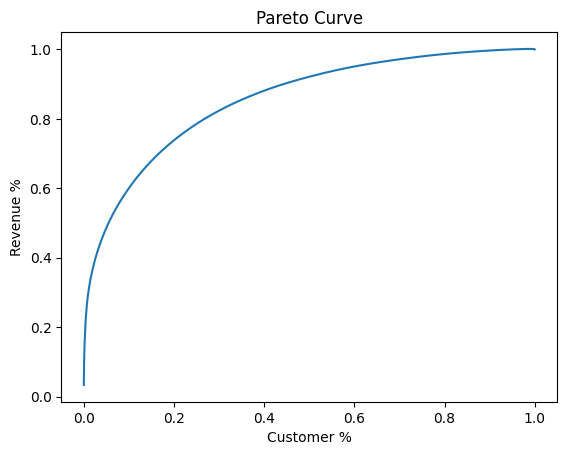

In [173]:
# Pareto analysis of customer revenue contribution
plt.plot(rfm_sorted['cum_customers'], rfm_sorted['cum_ratio'])
plt.xlabel('Customer %')
plt.ylabel('Revenue %')
plt.title('Pareto Curve')
plt.show()

In [200]:
#-----------------------------------
# Churn Analysis
#-----------------------------------
# 1.Define churned customers as those with no purchases in the last 60 days
snapshot_date = df_clean['InvoiceDate'].max() + pd.Timedelta(days=1)
df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
last_purchase = df_clean.groupby('CustomerID')['InvoiceDate'].max()
churn = last_purchase[last_purchase < snapshot_date - pd.Timedelta(days=60)]

In [175]:
# Calculate overall churn rate
churn_rate = len(churn)/ df_clean['CustomerID'].nunique()
churn_rate

0.4484099748341341

### Churn Rate Interpretation

The calculated churn rate includes both genuinely churned customers and one-time purchasers who naturally do not exhibit repeat purchase behavior. Therefore, this metric may overestimate actual customer attrition.

In [176]:
# Churn rate among active customers (excluding one-time purchasers)
active_customers = rfm[rfm['Frequency'] >= 2].index

churn_rate = len(set(churn.index) & set(active_customers)) / len(active_customers)

churn_rate

0.33801896044458973

### Active Customer Churn Insight

Even after excluding one-time purchasers, the churn rate remains at 34%, suggesting meaningful attrition among previously engaged customers and highlighting a key opportunity for retention strategies.

In [177]:
# RFM comparison : churned vs active customers
rfm['is_churn'] = rfm.index.isin(churn.index)
rfm.groupby('is_churn')[['Recency', 'Frequency', 'Monetary']].mean()

,Recency,Frequency,Monetary
is_churn,,,
False,22.137287,7.269183,2882.252040
True,178.083163,2.377551,687.792803


### RFM Comparison : Churned vs Active Customers

Churned customers show significantly higher recency, lower frequency, and monetary values compared to active customers, indicating, that engagement level is strongly associated with customer retention.

In [178]:
# Summary of churned customers within active customers
rfm[(rfm['Frequency'] >= 2) & (rfm['is_churn'] == True)] .describe()

,Recency,Frequency,Monetary
count,1034.000000,1034.000000,1034.000000
mean,149.072534,3.611219,1012.419277
std,78.120266,2.522255,1334.388302
min,60.000000,2.000000,-840.760000
25%,81.000000,2.000000,350.655000
50%,127.000000,3.000000,635.950000
75%,198.000000,4.000000,1178.505000
max,372.000000,35.000000,21535.900000


In [179]:
# Churned customers within VIP segment
set(vip_ids) & set(churn.index)

{12409.0,
 12435.0,
 12590.0,
 12637.0,
 12939.0,
 12980.0,
 13027.0,
 13093.0,
 14101.0,
 15749.0,
 15939.0,
 16180.0,
 16182.0,
 16553.0,
 16745.0}

In [180]:
vip_churn = list(set(vip_ids) & set(churn.index))
rfm.loc[vip_churn]

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,is_churn
CustomerID,,,,,,,,
15939.0,90.0,16.0,6102.26,2,5,5,255,True
13027.0,114.0,6.0,6912.00,2,4,5,245,True
13093.0,267.0,13.0,7741.47,1,5,5,155,True
15749.0,235.0,4.0,21535.90,1,4,5,145,True
16553.0,163.0,14.0,5664.57,2,5,5,255,True
16745.0,87.0,18.0,7170.70,2,5,5,255,True
12939.0,64.0,8.0,11581.80,3,5,5,355,True
12590.0,190.0,3.0,9861.38,1,3,5,135,True
12435.0,80.0,2.0,7829.89,2,2,5,225,True


In [181]:
# VIP churn rate
rfm.loc[vip_ids].mean(numeric_only=True)

,0
Recency,19.159817
Frequency,27.936073
Monetary,18415.843425
is_churn,0.068493


VIP churn rate was lower than the overall active customer churn rate, indicating that VIP customers exhibit higher loyalty and stronger engagement.

However, since VIP customers contribute a disproportionate share of total revenue, even a small amount of churn can have a significant impact on overall business performance.

This highlights the importance of targeted VIP retention strategies.

In [182]:
# Average RFM metrics for VIP customers
rfm.loc[vip_ids, ['Recency','Frequency','Monetary']].mean()

,0
Recency,19.159817
Frequency,27.936073
Monetary,18415.843425


In [183]:
# Average RFM metrics for churned VIP customers
rfm.loc[vip_churn, ['Recency', 'Frequency', 'Monetary']].mean()

,0
Recency,122.533333
Frequency,8.866667
Monetary,8754.275333


Churned VIP customers show a significant increase in recency and a decrease in frequency and monetary value compared to active VIP customers.

This suggests that VIP customers do not churn abruptly, but instead gradually disengage over time through declining activity levels.

Based on this pattern, a VIP risk detection system can be implemented to identify early signs of churn and enable proacitve retention strategies.


In [184]:
# Perform t-test between VIP and non-VIP customers

from scipy import stats

vip_monetary = rfm[rfm.index.isin(vip_ids)]['Monetary']
non_vip_monetary = rfm[~rfm.index.isin(vip_ids)]['Monetary']

t_stat, p_val = stats.ttest_ind(vip_monetary, non_vip_monetary)
print(f"T-statistic: {t_stat:.2f}")
print(f"P-value: {p_val:.2f}")

T-statistic: 34.39
P-value: 0.00


The t-test result showed a statistically significant difference between VIP and non-VIP customers (t = 34.39, p < 0.001).

In [185]:
# Calculate purchase intervals for each customer
purchase_dates = df_clean.sort_values(['CustomerID','InvoiceDate'])
purchase_dates['PrevInvoiceDate'] = purchase_dates.groupby('CustomerID')['InvoiceDate'].shift(1)
purchase_dates['DaysBetween'] = (purchase_dates['InvoiceDate']-purchase_dates['PrevInvoiceDate']).dt.days

# Calculate average purchase cycle excluding same-day purchases
avg_cycle = purchase_dates[purchase_dates["DaysBetween"] > 0]['DaysBetween'].mean()
avg_cycle

np.float64(39.52222754983218)

### Churn Threshold Definition

Purchase interval analysis showed that the average customer repurchase cycle was approximately 40 days.

Based on this pattern, customers with no purchase activity for more than 60 days were classified as churn-risk customers. The 60-day threshold was selected as approximately 1.5 times the average repurchase cycle, providing a sufficient inactivity buffer while reducing the risk of misclassifying temporarily inactive customers as churned.

In [186]:
# Identify customers with consistent vs irregular purchase behavior using standard deviation of purchase intervals
purchase_intervals = purchase_dates.groupby('CustomerID')['DaysBetween'].agg(['mean','std']).fillna(0)
purchase_intervals

,mean,std
CustomerID,,
12346.0,0.000000,0.000000
12347.0,2.000000,11.260551
12348.0,9.400000,34.088728
12349.0,0.000000,0.000000
12350.0,0.000000,0.000000
...,...,...
18280.0,0.000000,0.000000
18281.0,0.000000,0.000000
18282.0,9.833333,32.824141


In [187]:
# Identify churn-risk customers using statistical threshold (mean + 2 * std of purchase interval )
purchase_intervals['Upper_Bound'] = purchase_intervals['mean'] + (2 * purchase_intervals['std'])

# Statistically high churn-risk customers
rfm_advanced = rfm.join(purchase_intervals)
rfm_advanced['Is_Statistically_Churned'] = rfm_advanced['Recency'] > rfm_advanced['Upper_Bound']
rfm_advanced['Is_Statistically_Churned'].sum()

np.int64(2922)

### Churn Risk Index

A statistical threshold was applied to identify high-risk churn customers, defined as mean purchase cycle + 2 * standard deviations.

This approach captures abnormal inactivity patterns beyond normal customer behavior, enabling early detection of potential churn cases.

In [188]:
# Analyze changes in VIP customer purchase intervals
vip_data = df_clean[df_clean['CustomerID'].isin(vip_ids)].copy()
vip_data = vip_data.sort_values(['CustomerID', 'InvoiceDate'])

# Calculate time gaps between consecutive purchases for each customer
vip_data['Prev_Date'] = vip_data.groupby('CustomerID')['InvoiceDate'].shift(1)
vip_data['Days_Between'] = (vip_data['InvoiceDate'] - vip_data['Prev_Date']).dt.days

# Compare recent purchase cycles with historical average purchase behavior
velocity_check = vip_data.groupby('CustomerID').agg({'Days_Between' : ['mean', lambda x : x.tail(3).mean()]})
velocity_check.columns = ['Avg_Interval', 'Recent_3_Interval']
velocity_check['Slowing_Down'] = velocity_check['Recent_3_Interval'] > velocity_check['Avg_Interval']

# Extract VIP customers showing signs of purchasing slowdown
at_risk_vips = velocity_check[velocity_check['Slowing_Down'] == True]
print(f"Number of VIP customers showing slowing purchase behavior : {len(at_risk_vips)}")

Number of VIP customers showing slowing purchase behavior : 27


### VIP Purchase Slowdown Insight

A subset of VIP customers showed increasing purchase intervals, indicating early signs of customer disengagement and potential churn risk.

Given the high revenue contribution of VIP customers, these users represent a critical target segment where proactive retention strategies may deliver the greatest business impact.

In [189]:
at_risk_vips

,Avg_Interval,Recent_3_Interval,Slowing_Down
CustomerID,,,
12431.0,1.390756,8.000000,True
12590.0,0.289855,6.666667,True
12709.0,1.375000,4.000000,True
12798.0,22.857143,53.333333,True
12830.0,3.447368,17.666667,True
12921.0,0.474324,1.666667,True
12971.0,1.084691,1.333333,True
13050.0,0.812352,1.666667,True
13081.0,0.341856,3.333333,True


In [190]:
# Ratio of VIP customers with slowing purchase behavior
len(at_risk_vips)/len(vip_ids)

0.1232876712328767

In [191]:
# Risk Analysis : Return Behavior Analysis
# Calculate total sales amount for each customer
gross_revenue = df[df['Quantity'] > 0].groupby('CustomerID')['Revenue'].sum()

# Calculate total return amount for each customer
refund_revenue = df[df['Quantity'] <0].groupby('CustomerID')['Revenue'].sum().abs()

# Calculate return rate by customer
return_rate = (refund_revenue/gross_revenue).fillna(0)
rfm['Return_Rate'] = return_rate

# Identify high return rate VIP customers for monitoring
high_return_vips = rfm[(rfm.index.isin(vip_ids)) & (rfm['Return_Rate'] > 0.2)]
len(high_return_vips)

6

### High Return-Risk VIP Segment

VIP customers with return rates exceeding 20% were identified as a high-risk segment.

Although VIP customers are typically high-value customers, this group shows excessive return behavior, which may negatively impact profitability due to increased operational and logistics costs.

This segment is therefore flagged for return behavior monitoring and potential retention/risk management strategies.

In [201]:
# Cohort Analysis : customer retention over time
# Identify first purchase month for each customer
df_clean['OrderMonth'] = df_clean['InvoiceDate'].dt.to_period('M')
df_clean['CohortMonth'] = df_clean.groupby('CustomerID')['OrderMonth'].transform('min')

# Calculate cohort index (months since first purchase)
def get_date_int(df, column):
  year = df[column].dt.year
  month = df[column].dt.month
  return year, month

order_year, order_month = get_date_int(df_clean, 'OrderMonth')
cohort_year, cohort_month = get_date_int(df_clean, 'CohortMonth')

years_diff = order_year - cohort_year
months_diff = order_month - cohort_month

# Set first purchase month as cohort month 1
df_clean['CohortIndex'] = years_diff * 12 + months_diff + 1

# Calculate active customer count by cohort group
cohort_data = df_clean.groupby(['CohortMonth', 'CohortIndex'])['CustomerID'].nunique().reset_index()
cohort_counts = cohort_data.pivot(index='CohortMonth', columns = 'CohortIndex', values = 'CustomerID')

# Calculate customer retention rate by cohort
cohort_sizes = cohort_counts.iloc[:, 0]
retention = cohort_counts.divide(cohort_sizes, axis = 0)
retention.iloc[:, :5].round(3) * 100

CohortIndex,1,2,3,4,5
CohortMonth,,,,,
2010-12,100.0,38.2,33.4,38.7,36.0
2011-01,100.0,24.0,28.3,24.2,32.8
2011-02,100.0,24.7,19.2,27.9,26.8
2011-03,100.0,19.1,25.5,21.8,23.2
2011-04,100.0,22.7,22.1,21.1,20.7
2011-05,100.0,23.7,17.2,17.2,21.5
2011-06,100.0,20.9,18.7,27.2,24.7
2011-07,100.0,20.9,20.4,23.0,27.2
2011-08,100.0,25.1,25.1,25.1,13.8


In [193]:
rfm_advanced = rfm_advanced.join(rfm['Return_Rate'])

In [202]:
from google.colab import files
#files.download('Cananda_Ecom_Final_For_PBI.csv')

df_clean['InvoiceDate'] = pd.to_datetime(df_clean['InvoiceDate'])
df_clean['YearMonth'] = df_clean['InvoiceDate'].dt.to_period('M').astype(str)

transaction_data = df_clean[['CustomerID', 'InvoiceNo','InvoiceDate', 'YearMonth', 'Country', 'Quantity', 'UnitPrice', 'Revenue']]

transaction_data.to_csv('transaction_data.csv', index=False)
#files.download('transaction_data.csv')

In [195]:
customer_data = rfm_advanced.copy()
customer_data = customer_data.reset_index()

customer_data.to_csv('customer_data.csv', index=False)
#files.download('customer_data.csv')

In [196]:
at_risk_vips = at_risk_vips.reset_index()
at_risk_vips.to_csv("at_risk_vips.csv", index=False)
#files.download('at_risk_vips.csv')

In [197]:
customer_summary.to_csv("customer_summary.csv")
#files.download('customer_summary.csv')

### Data Export for Power BI

The processed datasets were exported as CSV files for further visualization and dashboard development in Power BI